In [1]:
import numpy as np
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

# --- load frozen artifacts from 03 ---
X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test  = pd.read_csv('../data/X_test_scaled.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()   # ravel: DataFrame -> 1-D
y_test  = pd.read_csv('../data/y_test.csv').values.ravel()

## Random Forest Classifier

In [2]:
print(X_train.shape)

(118936, 40)


In [3]:
# 1. Initialize the Random Forest Classifier
# You can adjust hyperparameters like n_estimators, max_depth, or random_state here
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model on your scaled training data
rf_model.fit(X_train, y_train)

# 3. Predict classes and probabilities on the test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# --- 4. Evaluate the Model ---
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# Calculate additional metrics imported in your notebook
roc_auc = roc_auc_score(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)
recall = recall_score(y_test, y_pred)

print(f"\nROC AUC Score: {roc_auc:.4f}")
print(f"Average Precision Score: {avg_precision:.4f}")
print(f"Recall Score: {recall:.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     22406
           1       0.92      0.61      0.74      7328

    accuracy                           0.89     29734
   macro avg       0.91      0.80      0.83     29734
weighted avg       0.90      0.89      0.88     29734

--- Confusion Matrix ---
[[22039   367]
 [ 2841  4487]]

ROC AUC Score: 0.8874
Average Precision Score: 0.8298
Recall Score: 0.6123


In [4]:
# 1. Initialize the Random Forest Classifier
# You can adjust hyperparameters like n_estimators, max_depth, or random_state here
rf_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced',  # Automatically adjusts weights inversely proportional to class frequencies
    random_state=42, 
    n_jobs=-1
)
# 2. Train the model on your scaled training data
rf_model.fit(X_train, y_train)

# 3. Predict classes and probabilities on the test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# --- 4. Evaluate the Model ---
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# Calculate additional metrics imported in your notebook
roc_auc = roc_auc_score(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)
recall = recall_score(y_test, y_pred)

print(f"\nROC AUC Score: {roc_auc:.4f}")
print(f"Average Precision Score: {avg_precision:.4f}")
print(f"Recall Score: {recall:.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     22406
           1       0.94      0.60      0.73      7328

    accuracy                           0.89     29734
   macro avg       0.91      0.79      0.83     29734
weighted avg       0.90      0.89      0.88     29734

--- Confusion Matrix ---
[[22121   285]
 [ 2940  4388]]

ROC AUC Score: 0.8875
Average Precision Score: 0.8292
Recall Score: 0.5988


In [5]:
!pip install xgboost

In [6]:
import re
from xgboost import XGBClassifier

X_train.columns = [re.sub(r'[\[\]<]', '', str(col)) for col in X_train.columns]
X_test.columns = [re.sub(r'[\[\]<]', '', str(col)) for col in X_test.columns]
# imbalance handling: ratio of negatives to positives
spw = (y_train == 0).sum() / (y_train == 1).sum()   # ~3.06

xgb = XGBClassifier(
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

proba = xgb.predict_proba(X_test)[:, 1]
preds = xgb.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC: ", average_precision_score(y_test, proba))
print(classification_report(y_test, preds))

ROC-AUC: 0.8933226146487976
PR-AUC:  0.8417797150365006
              precision    recall  f1-score   support

           0       0.91      0.92      0.92     22406
           1       0.76      0.73      0.74      7328

    accuracy                           0.87     29734
   macro avg       0.83      0.83      0.83     29734
weighted avg       0.87      0.87      0.87     29734



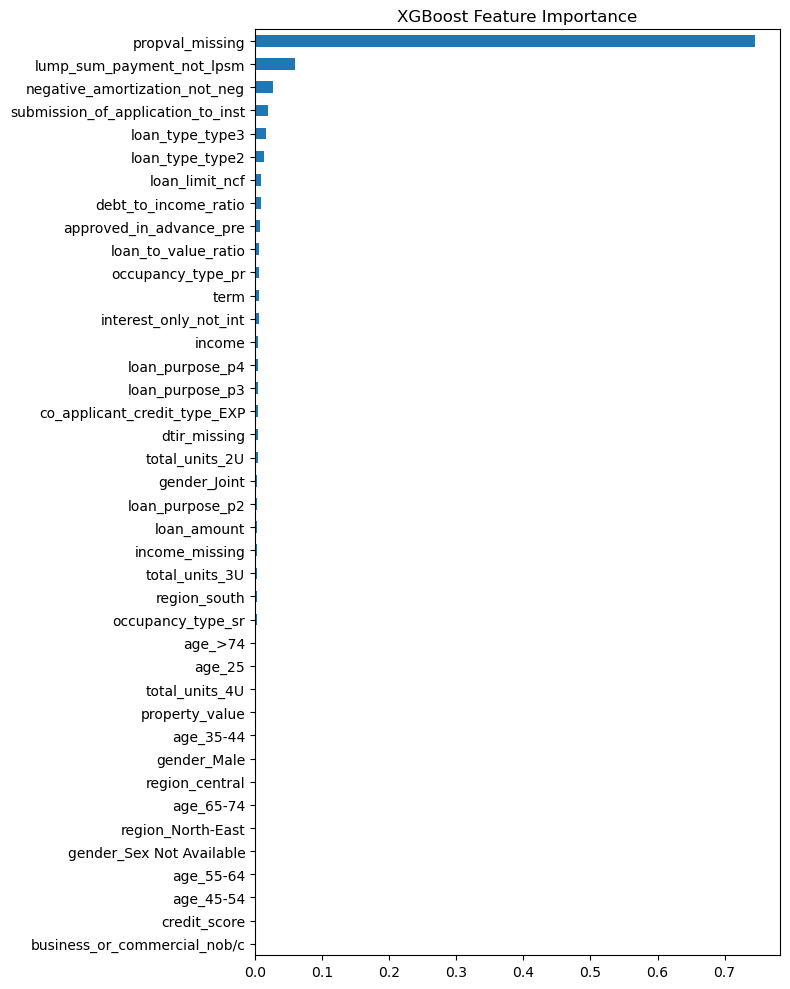

In [7]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
importances.sort_values().plot.barh(figsize=(8, 10))
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [8]:
df = pd.read_csv('../data/loan_features.csv')
print(df.groupby('status')['propval_missing'].mean())

status
0    0.000018
1    0.412020
Name: propval_missing, dtype: float64


In [9]:
for col in ['income_missing', 'dtir_missing', 'propval_missing']:
    print(col)
    print(df.groupby('status')[col].mean(), "\n")

income_missing
status
0    0.070614
1    0.033816
Name: income_missing, dtype: float64 

dtir_missing
status
0    0.069722
1    0.445154
Name: dtir_missing, dtype: float64 

propval_missing
status
0    0.000018
1    0.412020
Name: propval_missing, dtype: float64 



In [10]:
leaky = ['propval_missing', 'dtir_missing']
X_train_clean = X_train.drop(columns=leaky)
X_test_clean  = X_test.drop(columns=leaky)

spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=spw, random_state=42, eval_metric='logloss')
xgb.fit(X_train_clean, y_train)

proba = xgb.predict_proba(X_test_clean)[:, 1]
preds = xgb.predict(X_test_clean)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC: ", average_precision_score(y_test, proba))


ROC-AUC: 0.8933213996017131
PR-AUC:  0.8411165692508799


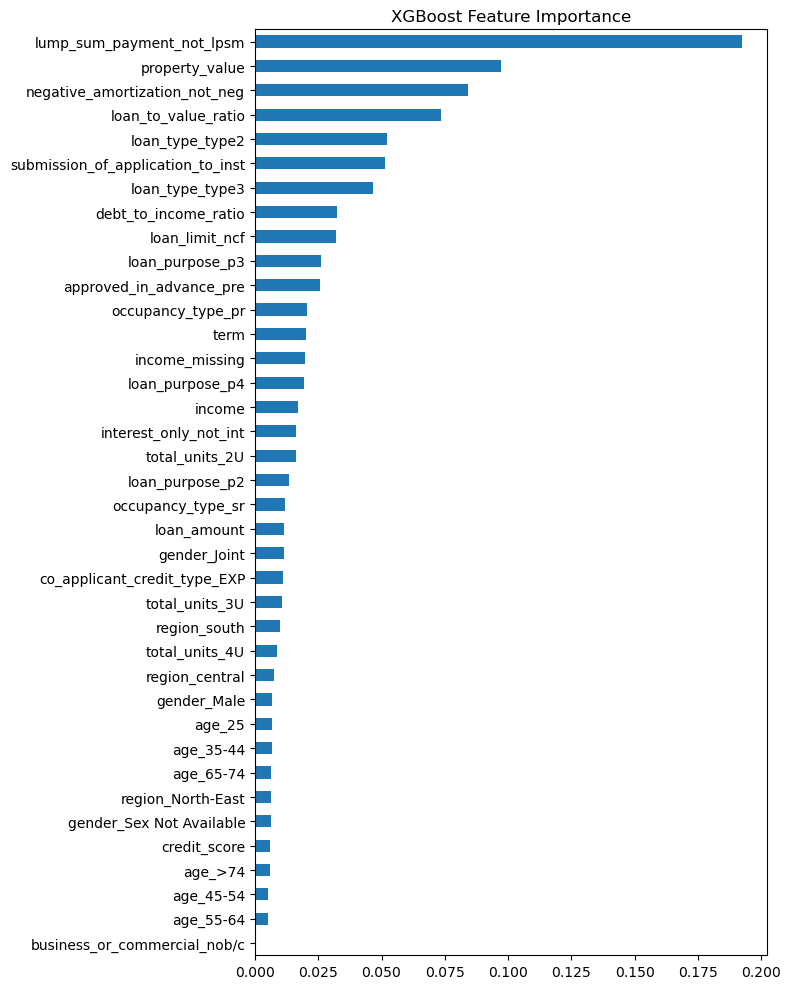

In [11]:
importances = pd.Series(xgb.feature_importances_, index=X_train_clean.columns)
importances.sort_values().plot.barh(figsize=(8, 10))
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [12]:
# clean refit, both models, same X_train_clean / X_test_clean
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_clean, y_train)
lr_proba = lr.predict_proba(X_test_clean)[:, 1]
lr_preds = lr.predict(X_test_clean)
print("ROC-AUC:", roc_auc_score(y_test, lr_proba))
print("LR  PR-AUC:", average_precision_score(y_test, lr_proba))
print("Recall: ", recall_score(y_test, lr_preds))


rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train_clean, y_train)
rf_proba = rf.predict_proba(X_test_clean)[:, 1]
rf_preds = rf.predict(X_test_clean)

print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print("RF  PR-AUC:", average_precision_score(y_test, rf_proba))
print("Recall: ", recall_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))


ROC-AUC: 0.7556268495513717
LR  PR-AUC: 0.5532650644457373
Recall:  0.6596615720524017
ROC-AUC: 0.8855237420565765
RF  PR-AUC: 0.8268349882843349
Recall:  0.5903384279475983
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     22406
           1       0.94      0.59      0.72      7328

    accuracy                           0.89     29734
   macro avg       0.91      0.79      0.83     29734
weighted avg       0.89      0.89      0.88     29734



In [13]:
print(classification_report(y_test, lr_preds))
print(classification_report(y_test, rf_preds))
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.87      0.72      0.79     22406
           1       0.44      0.66      0.53      7328

    accuracy                           0.71     29734
   macro avg       0.65      0.69      0.66     29734
weighted avg       0.76      0.71      0.72     29734

              precision    recall  f1-score   support

           0       0.88      0.99      0.93     22406
           1       0.94      0.59      0.72      7328

    accuracy                           0.89     29734
   macro avg       0.91      0.79      0.83     29734
weighted avg       0.89      0.89      0.88     29734

              precision    recall  f1-score   support

           0       0.91      0.92      0.92     22406
           1       0.75      0.73      0.74      7328

    accuracy                           0.87     29734
   macro avg       0.83      0.82      0.83     29734
weighted avg       0.87      0.87      0.87     29734



In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix

# --- cost assumptions (state these in your README) ---
COST_FN = 5   # missed default: approved a bad loan (expensive)
COST_FP = 1   # rejected a good borrower: lost interest (cheap)

# xgb_proba = your XGBoost P(default) on the test set
# (the predict_proba[:,1] from the clean XGBoost model)
xgb_proba = xgb.predict_proba(X_test_clean)[:, 1]
preds_t = xgb.predict(X_test_clean)
thresholds = np.arange(0.01, 1.00, 0.01)
results = []

for t in thresholds:
    preds_t = (xgb_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()
    total_cost = COST_FN * fn + COST_FP * fp
    results.append((t, fn, fp, total_cost))

results = pd.DataFrame(results, columns=['threshold', 'FN', 'FP', 'total_cost'])

# the winner: lowest total cost
best = results.loc[results['total_cost'].idxmin()]
print("Best threshold:", round(best['threshold'], 2))
print("At that threshold -> FN:", int(best['FN']), "| FP:", int(best['FP']), "| cost:", int(best['total_cost']))

Best threshold: 0.41
At that threshold -> FN: 1666 | FP: 3045 | cost: 11375


In [15]:
final_preds = (xgb_proba >= 0.52).astype(int)
print("Recall at 0.41:", recall_score(y_test, final_preds))
print("Precision at 0.41:", average_precision_score(y_test, final_preds))

Recall at 0.41: 0.7182041484716157
Precision at 0.41: 0.6261366609113193


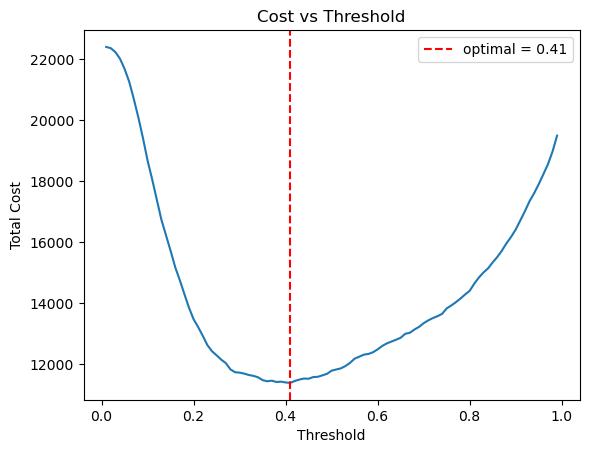

In [16]:
plt.plot(results['threshold'], results['total_cost'])
plt.axvline(0.41, color='red', linestyle='--', label='optimal = 0.41')
plt.xlabel('Threshold'); plt.ylabel('Total Cost'); plt.legend()
plt.title('Cost vs Threshold'); plt.show()

In [17]:
# clean feature artifacts (new files, nothing overwritten)
X_train_clean.to_csv("../data/X_train_clean.csv", index=False)
X_test_clean.to_csv("../data/X_test_clean.csv", index=False)

# clean model + threshold (re-save to be certain they're the clean versions)
joblib.dump(xgb, "../models/final_model_xgb_clean.pkl")
joblib.dump(0.41, "../models/ldecision_threshold.pkl")

print("Saved:", "X_train_clean.csv, X_test_clean.csv, final_model_xgb_clean.pkl, decision_threshold.pkl")

Saved: X_train_clean.csv, X_test_clean.csv, final_model_xgb_clean.pkl, decision_threshold.pkl
